In [1]:
import os

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import psutil
from matplotlib.lines import Line2D

import spatioloji_s as sj
from spatioloji_s.spatial import point as spoint
from spatioloji_s.spatial import polygon as spoly
from spatioloji_s.spatial.polygon.neighborhoods import harmonize_niches


In [2]:
sp = sj.data.spatioloji.from_pickle("xenium_data/processed_xenium_spatioloji.pkl")


Loading spatioloji from: xenium_data/processed_xenium_spatioloji.pkl
✓ Loaded: 1,134,555 cells × 5,001 genes


In [3]:
graph = spoint.build_knn_graph(sp, k=15, coord_type='global')

  ✓ KNN graph: k=15, 17018325 edges (directed), mean degree=15.0


In [4]:
sp.cell_meta['cell_group'] = sp.cell_meta['leiden'].astype(str)

In [5]:
mapping = {
    0: "Epi",
    1: "Epi",
    2: "stroma",
    3: "myeloid",
    4: "T",
    5: "Epi",
    6: "stroma",
    7: "stroma",
    8: "B"
}

sp.cell_meta['cell_group'] = sp.cell_meta['leiden'].map(mapping)

In [6]:
Interobj = spoint.identify_interface(sp, 
                              graph=graph,
                              group_col='cell_group',
                              region_a = "Epi",
                              region_b = "stroma",
                              method = 'density',
                              coord_type = 'global',
                              min_interface_cells = 15,
                              store = True, bandwidth=0.1)


[Interface/Point] Identifying interface: ['Epi'] vs ['stroma'] (method=density)
  Auto distance_threshold=18.4
  Stored 'interface_label' in cell_meta
  14965 interface cells (12182 region_a, 2783 region_b)
  8 segment(s)


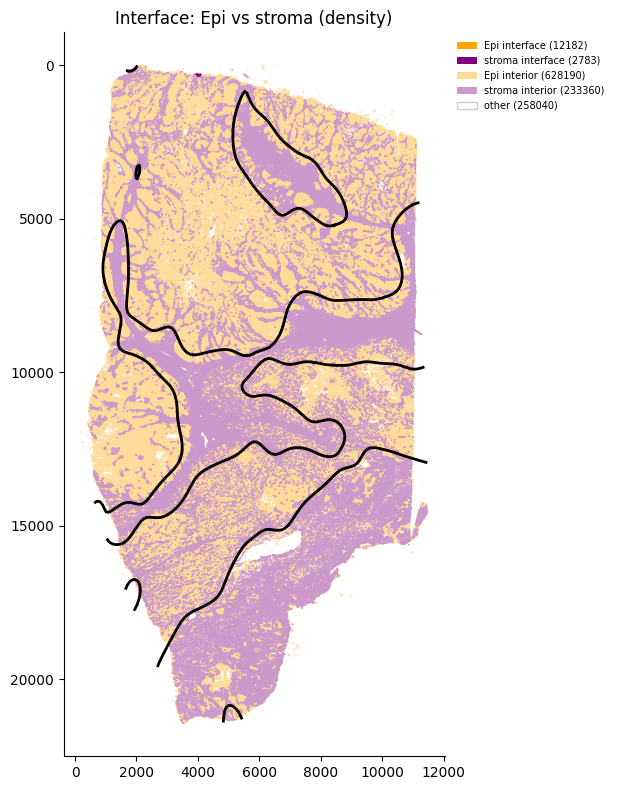

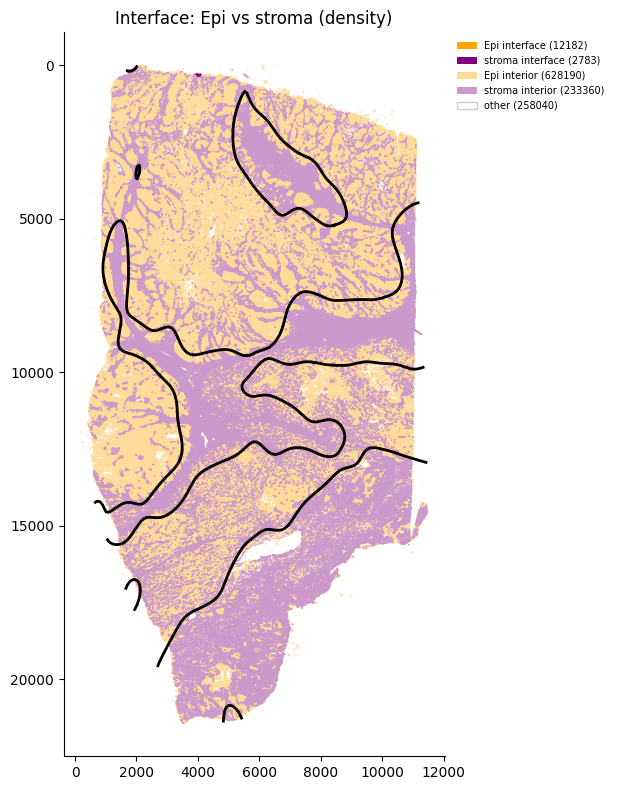

In [10]:
sj.visualization.plot_interface_point_map(sp,
                                          Interobj,
                                          show=True,
                                          dpi = 300,
                                          point_size=1, color_a='orange', color_b='purple',
                                          alpha=0.85)

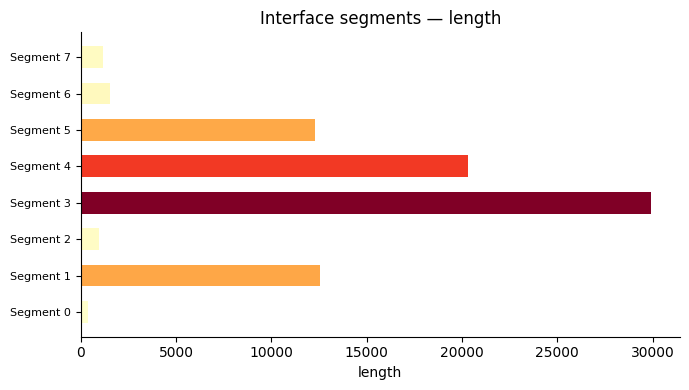

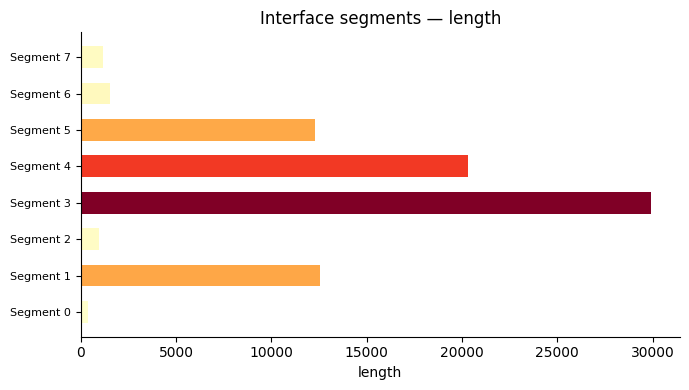

In [11]:
sj.visualization.plot_interface_point_metrics(Interobj, metric='length',
                                              show=True,
                                              dpi = 300)

/users/jiwang1/.conda/envs/spatioloji/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/users/jiwang1/.conda/envs/spatioloji/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/users/jiwang1/.conda/envs/spatioloji/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


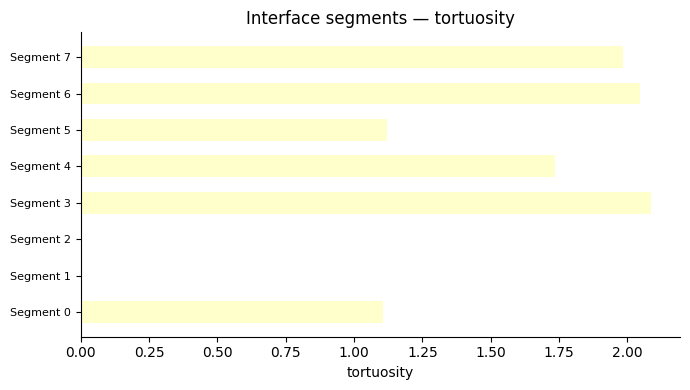

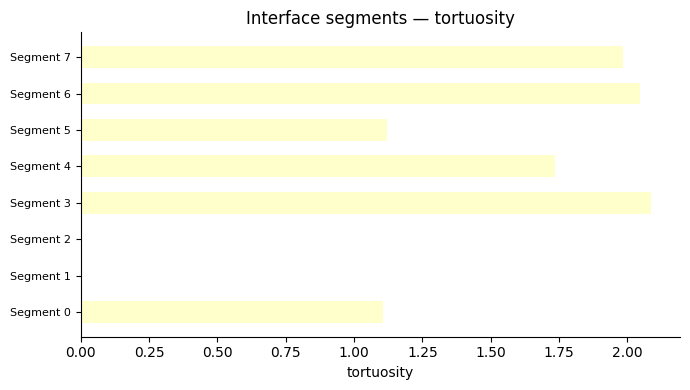

In [14]:
sj.visualization.plot_interface_point_metrics(Interobj, metric='tortuosity',
                                              show=True,
                                              dpi = 300)

In [13]:
# Compute expression gradient away from the interface                                                                                          
gradient_result = spoint.compute_gradient(                                                                                                   
  sp,
  interface_result=Interobj,
  genes=['EPCAM', 'VIM', 'COL3A1', 'MMP2'],                                                                                                              
  n_bins=20,                                                                                                                               
  max_distance=500,       # µm from interface                                                                                              
  coord_type='global',                                                                                                                           
  store=True,                                                                                                                              
) 

TypeError: compute_gradient() got an unexpected keyword argument 'layer'